## Final Project Submission

Please fill out:
* Student name: Teresia Njoki
* Student pace: full time
* Scheduled project review date/time: w
* Instructor name: Nikita Njoroge
* Blog post URL:


# BUSINESS PROBLEM
Your company now sees all the big companies creating original video content and they want to get in on the fun. They have decided to create a new movie studio, but they don’t know anything about creating movies. You are charged with exploring what types of films are currently doing the best at the box office. You must then translate those findings into actionable insights that the head of your company's new movie studio can use to help decide what type of films to create.

# BUSINESS OBJECTIVES
## 1.Box Office Performance Trends

-Analyze domestic vs. international earnings to understand which types of movies perform best globally.

-Identify top-grossing films and explore factors influencing profitability.

## 2. Genre-Based Performance
-Examine genre popularity over time, help determine trends in audience preferences.

Investigate content ratings (e.g., PG, R) and their impact on genre distribution and revenue.

## 3.Movie Ratings and Audience Reception
-Explore relationships between IMDb ratings and box office success.

-Identifiy patterns in audience reviews and how critical reception influences profitability.

## 4.Financial Trends in movie Budgets
-Analyze budget allocations and how spending correlates with box office success.

-Compare high-budget vs. low-budget films to evaluate cost-effectiveness.



# HYPOTHESIS TESTS
## Box Office Performance Hypotheses
Does higher international box office revenue correlate with higher overall profitability compared to domestic revenue?

Do movies with higher budgets generate significantly higher box office earnings than low-budget films?

## Genre-Based Hypotheses
Are multi-genre movies more successful in terms of audience ratings and revenue compared to single-genre films?

Do certain movie genres (e.g., Action, Adventure, Fantasy) consistently outperform others in global box office revenue?

## Ratings & Audience Reception Hypotheses
Are movies with higher IMDb ratings more profitable compared to those with lower ratings?

Does critical reception (fresh vs. rotten reviews) significantly influence box office success?

Do PG-13 rated movies generate higher revenue than R-rated or G-rated films?

## Financial Trends Hypotheses
Do production budgets have a statistically significant impact on worldwide revenue?

Are movies released in recent years generating higher total earnings compared to older releases?

In [3]:
#finding whats in the zippedata folder
!ls zippedData






bom.movie_gross.csv.gz
im.db.zip
rt.movie_info.tsv.gz
rt.reviews.tsv.gz
tmdb.movies.csv.gz
tn.movie_budgets.csv.gz


In [4]:
#extracting the im.db.zip-d file and saving as extracted files.
!unzip zippedData/im.db.zip -d ./extracted_files



Archive:  zippedData/im.db.zip
  inflating: ./extracted_files/im.db  


In [5]:
#check contents of extracted files
!ls extracted_files



im.db


In [6]:
#connecting to the sqlite database
import sqlite3
import pandas as pd

# Establish a connection to the database
conn = sqlite3.connect('./extracted_files/im.db')

# Query to list all tables in the database
tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(tables_query, conn)
print("Tables in the database:")
print(tables)

# Close the connection after you're done
#conn.close()



Tables in the database:
            name
0   movie_basics
1      directors
2      known_for
3     movie_akas
4  movie_ratings
5        persons
6     principals
7        writers


In [7]:
#reading data from the movie basics table
# Connect to the database 
conn = sqlite3.connect('./extracted_files/im.db')

# Load data from the movie_basics table
movie_basics = pd.read_sql_query("SELECT * FROM movie_basics LIMIT 5", conn)
print(movie_basics.head())




    movie_id                    primary_title              original_title  \
0  tt0063540                        Sunghursh                   Sunghursh   
1  tt0066787  One Day Before the Rainy Season             Ashad Ka Ek Din   
2  tt0069049       The Other Side of the Wind  The Other Side of the Wind   
3  tt0069204                  Sabse Bada Sukh             Sabse Bada Sukh   
4  tt0100275         The Wandering Soap Opera       La Telenovela Errante   

   start_year  runtime_minutes                genres  
0        2013            175.0    Action,Crime,Drama  
1        2019            114.0       Biography,Drama  
2        2018            122.0                 Drama  
3        2018              NaN          Comedy,Drama  
4        2017             80.0  Comedy,Drama,Fantasy  


In [8]:
#reading data from movie ratings table
# Connect to the database 
conn = sqlite3.connect('./extracted_files/im.db')

# Load data from the movie_ratings table
movie_ratings = pd.read_sql_query("SELECT * FROM movie_ratings LIMIT 5", conn)
print(movie_ratings.head())




     movie_id  averagerating  numvotes
0  tt10356526            8.3        31
1  tt10384606            8.9       559
2   tt1042974            6.4        20
3   tt1043726            4.2     50352
4   tt1060240            6.5        21


## Exploring the imdb dataset by running some SQL queries to extract meaningful insights we will look at:
   i)Top rated movies
   
   ii)Most common movie genres
   
   iii)movies with high ratings and significant votes
   
   iv)Oldest and newest movies
   
   v)movies that belong to multiple genres and their rating
   
   


In [9]:
pd.read_sql("PRAGMA table_info(movie_ratings);", conn)


,cid,name,type,notnull,dflt_value,pk
0,0,movie_id,TEXT,0,None,0
1,1,averagerating,REAL,0,None,0
2,2,numvotes,INTEGER,0,None,0


In [10]:
#top rated movies

q=pd.read_sql("""
SELECT mb.primary_title, mb.genres, mr.averagerating, mr.numvotes
FROM movie_basics mb
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
ORDER BY mr.averagerating DESC
LIMIT 10;
""",conn)
q


,primary_title,genres,averagerating,numvotes
0,Exteriores: Mulheres Brasileiras na Diplomacia,Documentary,10.0,5
1,The Dark Knight: The Ballad of the N Word,"Comedy,Drama",10.0,5
2,Freeing Bernie Baran,"Crime,Documentary",10.0,5
3,Hercule contre Hermès,Documentary,10.0,5
4,I Was Born Yesterday!,Documentary,10.0,6
5,Dog Days in the Heartland,Drama,10.0,5
6,Revolution Food,Documentary,10.0,8
7,Fly High: Story of the Disc Dog,Documentary,10.0,7
8,All Around Us,Documentary,10.0,6
9,The Paternal Bond: Barbary Macaques,Documentary,10.0,5


In [11]:
#most common movie genres
q=pd.read_sql("""
SELECT genres,COUNT(*) AS genre_count
FROM movie_basics
GROUP BY genres
ORDER BY genre_count DESC
LIMIT 10;
""",conn)
q
                            
    





,genres,genre_count
0,Documentary,32185
1,Drama,21486
2,Comedy,9177
3,None,5408
4,Horror,4372
5,"Comedy,Drama",3519
6,Thriller,3046
7,Action,2219
8,"Biography,Documentary",2115
9,"Drama,Romance",2079


In [12]:
#movies with high rating and significant votes.
q=pd.read_sql("""
SELECT mb.primary_title, mb.genres, mr.averagerating, mr.numvotes 
FROM movie_basics mb 
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id 
WHERE mr.numvotes > 1000 AND mr.averagerating > 5
ORDER BY mr.averagerating DESC, mr.numvotes DESC 
LIMIT 10;
""",conn)
q

,primary_title,genres,averagerating,numvotes
0,Once Upon a Time ... in Hollywood,"Comedy,Drama",9.7,5600
1,Ekvtime: Man of God,"Biography,Drama,History",9.6,2604
2,I Want to Live,"Adventure,Biography,Documentary",9.6,1339
3,Aloko Udapadi,"Drama,History",9.5,6509
4,Peranbu,Drama,9.4,9629
5,The Mountain II,"Action,Drama,War",9.3,100568
6,Aynabaji,"Crime,Mystery,Thriller",9.3,18470
7,Wheels,Drama,9.3,17308
8,Truth and Justice,Drama,9.3,1220
9,CM101MMXI Fundamentals,"Comedy,Documentary",9.2,41560


In [13]:
#oldest and newest movies
#Oldest
q=pd.read_sql("""
SELECT primary_title,start_year,genres
FROM movie_basics
ORDER BY start_year ASC
LIMIT 10;
""",conn)
q

,primary_title,start_year,genres
0,Pál Adrienn,2010,Drama
1,So Much for Justice!,2010,History
2,Children of the Green Dragon,2010,Drama
3,The Final Journey,2010,Drama
4,Quantum Quest: A Cassini Space Odyssey,2010,"Adventure,Animation,Sci-Fi"
5,The Overnight,2010,None
6,In My Sleep,2010,"Drama,Mystery,Thriller"
7,This Wretched Life,2010,"Comedy,Drama"
8,Blind Sided,2010,"Comedy,Crime,Drama"
9,The Payback Man,2010,"Crime,Drama,Thriller"


In [14]:
#oldest and newest movies
#newest
q=pd.read_sql("""
SELECT primary_title,start_year,genres
FROM movie_basics
ORDER BY start_year DESC
LIMIT 10;
""",conn)
q

,primary_title,start_year,genres
0,100 Years,2115,Drama
1,Avatar 5,2027,"Action,Adventure,Fantasy"
2,Untitled Star Wars Film,2026,Fantasy
3,Avatar 4,2025,"Action,Adventure,Fantasy"
4,Untitled Star Wars Film,2024,None
5,Fantastic Beasts and Where to Find Them 5,2024,"Adventure,Family,Fantasy"
6,Untitled Marvel Project,2023,Action
7,Untitled Disney Live-Action Project,2023,None
8,Avatar 3,2023,"Action,Adventure,Drama"
9,Wraith of the Umbra and Eidolon II,2023,"Adventure,Drama,Fantasy"


In [15]:
#movies with high rating and signifacant votes with their release dates.
q=pd.read_sql("""
SELECT mb.primary_title, mb.start_year, mb.genres, mr.averagerating, mr.numvotes 
FROM movie_basics mb 
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id 
WHERE mr.numvotes > 1000 AND mr.averagerating > 7.5 
ORDER BY mr.averagerating DESC, mr.numvotes DESC 
LIMIT 10;
""",conn)
q

,primary_title,start_year,genres,averagerating,numvotes
0,Once Upon a Time ... in Hollywood,2019,"Comedy,Drama",9.7,5600
1,Ekvtime: Man of God,2018,"Biography,Drama,History",9.6,2604
2,I Want to Live,2015,"Adventure,Biography,Documentary",9.6,1339
3,Aloko Udapadi,2017,"Drama,History",9.5,6509
4,Peranbu,2018,Drama,9.4,9629
5,The Mountain II,2016,"Action,Drama,War",9.3,100568
6,Aynabaji,2016,"Crime,Mystery,Thriller",9.3,18470
7,Wheels,2014,Drama,9.3,17308
8,Truth and Justice,2019,Drama,9.3,1220
9,CM101MMXI Fundamentals,2013,"Comedy,Documentary",9.2,41560


In [16]:
#movies with multiple genres
q=pd.read_sql("""
SELECT primary_title, genres, start_year 
FROM movie_basics 
WHERE genres LIKE '%,%' 
ORDER BY start_year DESC 
LIMIT 10;
""",conn)
q

,primary_title,genres,start_year
0,Avatar 5,"Action,Adventure,Fantasy",2027
1,Avatar 4,"Action,Adventure,Fantasy",2025
2,Fantastic Beasts and Where to Find Them 5,"Adventure,Family,Fantasy",2024
3,Avatar 3,"Action,Adventure,Drama",2023
4,Wraith of the Umbra and Eidolon II,"Adventure,Drama,Fantasy",2023
5,Mi Asesino Favorito,"Comedy,Crime",2022
6,Nepotism Kingdom,"Action,Drama,Thriller",2022
7,Drain Baby,"Comedy,Drama,Fantasy",2022
8,Minecraft the First Movie,"Action,Adventure,Documentary",2022
9,Fantastic Beasts and Where to Find Them 4,"Adventure,Family,Fantasy",2022


In [17]:
#multiple genres with high rating
q=pd.read_sql("""
SELECT mb.primary_title, mb.genres, mb.start_year, mr.averagerating, mr.numvotes 
FROM movie_basics mb 
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id 
WHERE mr.averagerating > 7.5 
AND mr.numvotes > 1000 
AND mb.genres LIKE '%,%' -- Ensures the movie has multiple genres
ORDER BY mr.averagerating DESC, mr.numvotes DESC 
LIMIT 10;
""",conn)
q


,primary_title,genres,start_year,averagerating,numvotes
0,Once Upon a Time ... in Hollywood,"Comedy,Drama",2019,9.7,5600
1,Ekvtime: Man of God,"Biography,Drama,History",2018,9.6,2604
2,I Want to Live,"Adventure,Biography,Documentary",2015,9.6,1339
3,Aloko Udapadi,"Drama,History",2017,9.5,6509
4,The Mountain II,"Action,Drama,War",2016,9.3,100568
5,Aynabaji,"Crime,Mystery,Thriller",2016,9.3,18470
6,CM101MMXI Fundamentals,"Comedy,Documentary",2013,9.2,41560
7,Natsamrat,"Drama,Family",2016,9.2,4297
8,Caur Adatu,"Biography,Documentary,Drama",2014,9.2,1119
9,The Weight of Chains 2,"Comedy,Documentary,History",2014,9.2,1015


In [94]:
merged_movies = movie_basics.merge(movie_ratings, on='movie_id', how='left')



In [97]:
print(merged_movies.head())


    movie_id                    primary_title              original_title  \
0  tt0063540                        Sunghursh                   Sunghursh   
1  tt0066787  One Day Before the Rainy Season             Ashad Ka Ek Din   
2  tt0069049       The Other Side of the Wind  The Other Side of the Wind   
3  tt0069204                  Sabse Bada Sukh             Sabse Bada Sukh   
4  tt0100275         The Wandering Soap Opera       La Telenovela Errante   

   start_year  runtime_minutes                genres  averagerating  numvotes  
0        2013            175.0    Action,Crime,Drama            NaN       NaN  
1        2019            114.0       Biography,Drama            NaN       NaN  
2        2018            122.0                 Drama            NaN       NaN  
3        2018              NaN          Comedy,Drama            NaN       NaN  
4        2017             80.0  Comedy,Drama,Fantasy            NaN       NaN  


In [101]:
merged_movies = movie_basics.merge(movie_ratings, on='movie_id', how='left')
merged_movies


,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama",NaN,NaN
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama",NaN,NaN
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama,NaN,NaN
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama",NaN,NaN
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy",NaN,NaN


In [102]:
#top movies with highest rating
merged_movies.sort_values(by='averagerating', ascending=False)[['primary_title', 'genres', 'averagerating']].head(10)


,primary_title,genres,averagerating
0,Sunghursh,"Action,Crime,Drama",NaN
1,One Day Before the Rainy Season,"Biography,Drama",NaN
2,The Other Side of the Wind,Drama,NaN
3,Sabse Bada Sukh,"Comedy,Drama",NaN
4,The Wandering Soap Opera,"Comedy,Drama,Fantasy",NaN


# Exploring bom.movie_gross.csv.gz to help us analyze financial success of movies
## BY:

 i)Top- grossing movies
 
 ii)Domestic vs international earnings
 
 iii)Trends over time


In [18]:
import pandas as pd

# Load the dataset
df = pd.read_csv('./zippedData/bom.movie_gross.csv.gz')

# Display the first few rows
df.head()



,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [19]:
#check available columns
df.columns

Index(['title', 'studio', 'domestic_gross', 'foreign_gross', 'year'], dtype='object')

In [20]:
#find datatypes of above columns
print(df.dtypes)

title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object


In [ ]:
print(df.dtypes)

In [21]:
#converting the foreign_gross to numeric
df['foreign_gross'] = pd.to_numeric(df['foreign_gross'], errors='coerce')



In [22]:
#rank movies by total global earnings(domestic+foreign)
df['total_gross'] = df['domestic_gross'] + df['foreign_gross']
top_movies = df.sort_values(by='total_gross', ascending=False).head(10)
top_movies[['title', 'year', 'total_gross']]


,title,year,total_gross
727,Marvel's The Avengers,2012,1.518900e+09
1875,Avengers: Age of Ultron,2015,1.405400e+09
3080,Black Panther,2018,1.347000e+09
328,Harry Potter and the Deathly Hallows Part 2,2011,1.341500e+09
2758,Star Wars: The Last Jedi,2017,1.332600e+09
3081,Jurassic World: Fallen Kingdom,2018,1.309500e+09
1127,Frozen,2013,1.276400e+09
2759,Beauty and the Beast (2017),2017,1.263500e+09
3082,Incredibles 2,2018,1.242800e+09
1128,Iron Man 3,2013,1.214800e+09


In [23]:
#checking for missing values
df[['domestic_gross', 'foreign_gross']].isna().sum()


domestic_gross      28
foreign_gross     1355
dtype: int64

In [24]:
#summarizing domestic vs foreign earning.
df[['domestic_gross', 'foreign_gross']].describe()


,domestic_gross,foreign_gross
count,3.359000e+03,2.032000e+03
mean,2.874585e+07,7.505704e+07
std,6.698250e+07,1.375294e+08
min,1.000000e+02,6.000000e+02
25%,1.200000e+05,3.775000e+06
50%,1.400000e+06,1.890000e+07
75%,2.790000e+07,7.505000e+07
max,9.367000e+08,9.605000e+08


In [25]:
#comparing proportions.
df['total_gross'] = df['domestic_gross'] + df['foreign_gross']
df['domestic_percent'] = (df['domestic_gross'] / df['total_gross']) * 100
df['foreign_percent'] = (df['foreign_gross'] / df['total_gross']) * 100

df[['title', 'domestic_percent', 'foreign_percent']].head(10)  # View top movies


,title,domestic_percent,foreign_percent
0,Toy Story 3,38.894096,61.105904
1,Alice in Wonderland (2010),32.588981,67.411019
2,Harry Potter and the Deathly Hallows Part 1,30.823701,69.176299
3,Inception,35.325365,64.674635
4,Shrek Forever After,31.716715,68.283285
5,The Twilight Saga: Eclipse,43.020759,56.979241
6,Iron Man 2,50.072127,49.927873
7,Tangled,33.930382,66.069618
8,Despicable Me,46.308231,53.691769
9,How to Train Your Dragon,43.968478,56.031522


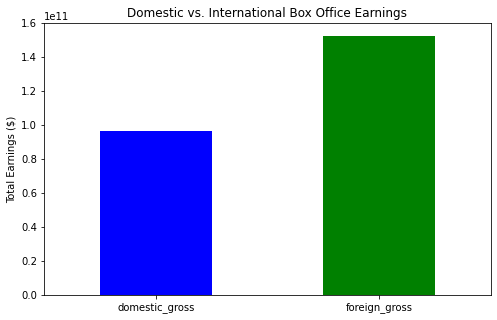

In [26]:
#visualize earnings.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df[['domestic_gross', 'foreign_gross']].sum().plot(kind='bar', color=['blue', 'green'])
plt.ylabel('Total Earnings ($)')
plt.title('Domestic vs. International Box Office Earnings')
plt.xticks(rotation=0)
plt.show()


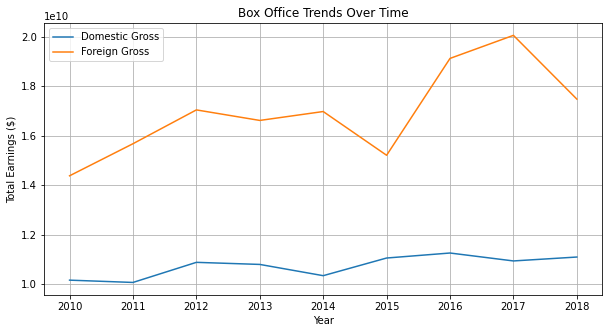

In [27]:
#trends overtime
#total domestic and foreign earnings for each year
df.groupby('year')[['domestic_gross', 'foreign_gross']].sum().plot(kind='line', figsize=(10, 5))
plt.xlabel('Year')
plt.ylabel('Total Earnings ($)')
plt.title('Box Office Trends Over Time')
plt.legend(['Domestic Gross', 'Foreign Gross'])
plt.grid(True)
plt.show()


In [28]:
#find the highest grossing years
df.groupby('year')[['domestic_gross', 'foreign_gross']].sum().sort_values(by='domestic_gross', ascending=False).head(10)


,domestic_gross,foreign_gross
year,,
2016,1.125365e+10,1.911904e+10
2018,1.109121e+10,1.747449e+10
2015,1.105141e+10,1.520395e+10
2017,1.093327e+10,2.005093e+10
2012,1.087661e+10,1.703789e+10
2013,1.079233e+10,1.661239e+10
2014,1.033774e+10,1.697197e+10
2010,1.015693e+10,1.437426e+10
2011,1.006416e+10,1.567099e+10


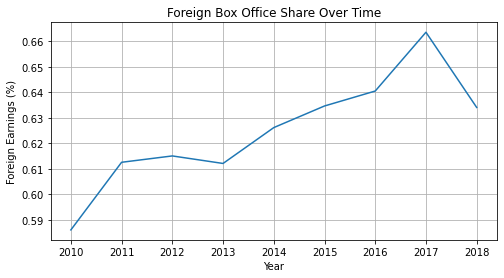

In [29]:
#compare domestic vs foreign share over time
#how earnings changed overtime(over the years)
df['total_gross'] = df['domestic_gross'] + df['foreign_gross']
df.groupby('year').apply(lambda x: x['foreign_gross'].sum() / x['total_gross'].sum()).plot(kind='line', figsize=(8, 4))

plt.xlabel('Year')
plt.ylabel('Foreign Earnings (%)')
plt.title('Foreign Box Office Share Over Time')
plt.grid(True)
plt.show()


# rt.movie_info.tsv.gz dataset

   i) highest rated movies based on reviews
   
   ii)comparison of critic vs audience ratings
   
   iii)Trends in movie release years
   
   iv)Genre-based patterns in ratings
   
   v)rating and total box office earning


In [30]:
import pandas as pd

# Load the dataset with the correct delimiter
df_rt = pd.read_csv('./zippedData/rt.movie_info.tsv.gz', delimiter='\t')

# Display the first few rows
df_rt.head()


,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,currency,box_office,runtime,studio
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,"Oct 9, 1971","Sep 25, 2001",NaN,NaN,104 minutes,NaN
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,"Aug 17, 2012","Jan 1, 2013",$,"600,000",108 minutes,Entertainment One
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,"Sep 13, 1996","Apr 18, 2000",NaN,NaN,116 minutes,NaN
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,"Dec 9, 1994","Aug 27, 1997",NaN,NaN,128 minutes,NaN
4,7,NaN,NR,Drama|Romance,Rodney Bennett,Giles Cooper,NaN,NaN,NaN,NaN,200 minutes,NaN


In [31]:
#checking dataset structure
df_rt.info()
df_rt.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1560 non-null   int64 
 1   synopsis      1498 non-null   object
 2   rating        1557 non-null   object
 3   genre         1552 non-null   object
 4   director      1361 non-null   object
 5   writer        1111 non-null   object
 6   theater_date  1201 non-null   object
 7   dvd_date      1201 non-null   object
 8   currency      340 non-null    object
 9   box_office    340 non-null    object
 10  runtime       1530 non-null   object
 11  studio        494 non-null    object
dtypes: int64(1), object(11)
memory usage: 146.4+ KB


Index(['id', 'synopsis', 'rating', 'genre', 'director', 'writer',
       'theater_date', 'dvd_date', 'currency', 'box_office', 'runtime',
       'studio'],
      dtype='object')

In [32]:
#top rated movies,their genres and their directors
df_rt.sort_values(by='rating', ascending=False).head(10)[['id', 'rating', 'genre', 'director']]


,id,rating,genre,director
0,1,R,Action and Adventure|Classics|Drama,William Friedkin
388,503,R,Art House and International|Classics|Drama|Hor...,Peter Sasdy
728,935,R,Comedy,David Hillenbrand|Scott Hillenbrand
730,937,R,Classics|Comedy|Drama,Melvin Van Peebles
733,941,R,Action and Adventure|Comedy,Martyn Burke
737,947,R,Drama|Mystery and Suspense,Steven Spielberg
738,949,R,Art House and International|Drama,Rainer Werner Fassbinder
740,952,R,Drama,Cyrus Nowrasteh
744,961,R,Comedy|Drama,Roman Coppola
746,963,R,Drama,James Cox


In [33]:
df_rt['rating'].describe()


count     1557
unique       6
top          R
freq       521
Name: rating, dtype: object

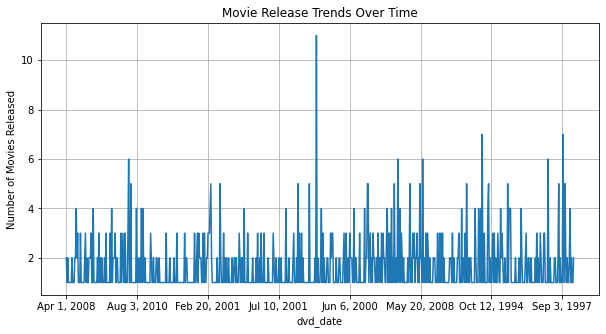

In [34]:
#trends in movie releases
df_rt['dvd_date'].value_counts().sort_index().plot(kind='line', figsize=(10, 5))
plt.xlabel('dvd_date')
plt.ylabel('Number of Movies Released')
plt.title('Movie Release Trends Over Time')
plt.grid(True)
plt.show()



In [35]:
#check genre distribution
df_rt['genre'].value_counts().head(10)


Drama                                              151
Comedy                                             110
Comedy|Drama                                        80
Drama|Mystery and Suspense                          67
Art House and International|Drama                   62
Action and Adventure|Drama                          42
Action and Adventure|Drama|Mystery and Suspense     40
Drama|Romance                                       35
Comedy|Romance                                      32
Horror                                              31
Name: genre, dtype: int64

In [48]:
#count movies by rating
df_rt['rating'].value_counts()


R        521
NR       503
PG       240
PG-13    235
G         57
NC17       1
Name: rating, dtype: int64

In [53]:
#genre distribution by rating
import pandas as pd

# Group by rating and count genres
genre_counts = df_rt.groupby(['rating', 'genre']).size().reset_index(name='count')

# Sort by count in descending order
genre_counts = genre_counts.sort_values(by='count', ascending=False)

# Display the first 10 rows
genre_counts.head(10)


,rating,genre,count
486,R,Drama,64
457,R,Comedy,46
182,NR,Drama,43
492,R,Drama|Mystery and Suspense,42
461,R,Comedy|Drama,42
353,PG-13,Comedy,36
116,NR,Art House and International|Drama,34
370,PG-13,Drama,26
500,R,Horror,20
411,R,Action and Adventure|Drama|Mystery and Suspense,18


In [54]:
df_rt.groupby('rating')['genre'].value_counts().head(10)


rating  genre                                                                                     
G       Classics|Comedy|Musical and Performing Arts|Romance                                           3
        Classics|Drama                                                                                3
        Action and Adventure|Kids and Family|Science Fiction and Fantasy                              2
        Animation|Kids and Family                                                                     2
        Animation|Kids and Family|Science Fiction and Fantasy                                         2
        Art House and International|Drama                                                             2
        Classics|Comedy|Drama|Musical and Performing Arts                                             2
        Classics|Drama|Mystery and Suspense                                                           2
        Kids and Family|Science Fiction and Fantasy                  

In [56]:
print(df_rt['box_office'].dtype)



object


In [57]:
df_rt[['box_office']].dropna().sample(10)


,box_office
966,"257,704,099"
234,"5,600,000"
1323,"95,111,012"
1248,"1,626,909"
782,"42,500,000"
1509,"2,646,396"
18,"20,518,224"
907,"4,300,353"
1212,"33,408,732"
1396,"2,500,000"


In [58]:
df_rt['box_office'] = df_rt['box_office'].str.replace(',', '', regex=True).astype(float)


In [59]:
#show movie rating and total box office earnings
df_rt.groupby('rating')['box_office'].sum()


rating
G        2.740316e+08
NC17     1.260219e+06
NR       4.723872e+07
PG       2.653745e+09
PG-13    6.612858e+09
R        3.298910e+09
Name: box_office, dtype: float64

In [60]:
#sorts them in descending order
df_rt.groupby('rating')['box_office'].sum().sort_values(ascending=False)


rating
PG-13    6.612858e+09
R        3.298910e+09
PG       2.653745e+09
G        2.740316e+08
NR       4.723872e+07
NC17     1.260219e+06
Name: box_office, dtype: float64

# rt.reviews.tsv.gz

2)Review freshness (fresh/rotten)

3)Top publishers and critics

4)Trends in review dates

In [67]:
import pandas as pd

df_reviews=pd.read_csv('./zippedData/rt.reviews.tsv.gz',sep='\t', encoding='latin1')
df_reviews.head()

,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"


In [68]:
#find most frequent publishers
df_reviews['publisher'].value_counts().head(10)


eFilmCritic.com         673
EmanuelLevy.Com         591
New York Times          590
Washington Post         565
Entertainment Weekly    541
Time Out                540
Chicago Sun-Times       506
Variety                 497
Austin Chronicle        484
Filmcritic.com          470
Name: publisher, dtype: int64

In [69]:
#to find critics with the most reviews(this reveals critics who have reviwed most movies)
df_reviews['critic'].value_counts().head(10)


Emanuel Levy           595
Roger Ebert            461
Dennis Schwartz        413
Nell Minow             372
James Berardinelli     348
Frank Swietek          348
Jeffrey M. Anderson    342
Philip Martin          332
Ken Hanke              285
Scott Weinberg         276
Name: critic, dtype: int64

In [70]:
#to find out publishers that give more positive reviews in percentage
df_reviews.groupby('publisher')['fresh'].value_counts(normalize=True).unstack()


fresh,fresh,rotten
publisher,,
2UE That Movie Show,0.950000,0.050000
3AW,0.761905,0.238095
3BlackChicks Review,0.461538,0.538462
48 Hills,1.000000,NaN
4Columns,0.500000,0.500000
...,...,...
thelondonpaper,0.600000,0.400000
tonymacklin.net,0.576923,0.423077
tonymedley.com,0.581395,0.418605


,publisher,review_count
0,eFilmCritic.com,673
1,EmanuelLevy.Com,591
2,New York Times,590
3,Washington Post,565
4,Entertainment Weekly,541
5,Time Out,540
6,Chicago Sun-Times,506
7,Variety,497
8,Austin Chronicle,484
9,Filmcritic.com,470


In [72]:
#review trends
df_reviews['date'] = pd.to_datetime(df_reviews['date'], errors='coerce')


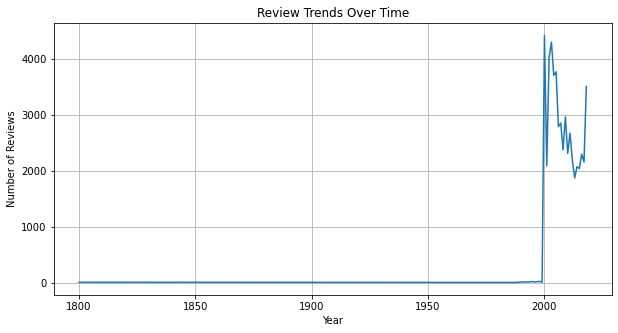

In [73]:
#check how review has changed over time
df_reviews['year'] = df_reviews['date'].dt.year
df_reviews['year'].value_counts().sort_index().plot(kind='line', figsize=(10, 5))
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.title('Review Trends Over Time')
plt.grid(True)
plt.show()


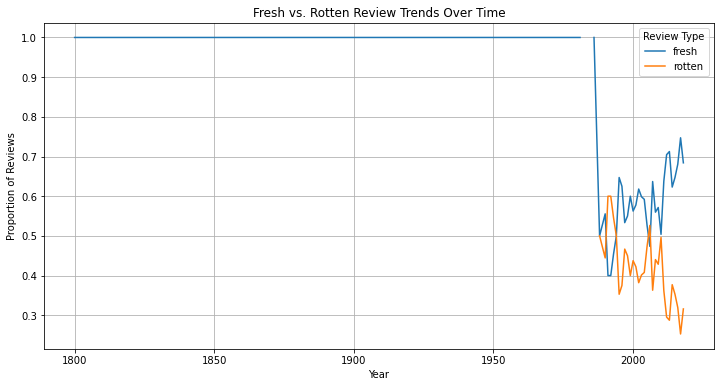

In [74]:
#see how negative vs positive reviews change over time
df_reviews.groupby('year')['fresh'].value_counts(normalize=True).unstack().plot(kind='line', figsize=(12, 6))
plt.xlabel('Year')
plt.ylabel('Proportion of Reviews')
plt.title('Fresh vs. Rotten Review Trends Over Time')
plt.legend(title='Review Type')
plt.grid(True)
plt.show()


In [75]:
#merging datasets
df_combined = df_rt.merge(df_reviews, on='id', how='inner')


In [78]:
df_combined['publisher'].value_counts().head(10)



eFilmCritic.com         673
EmanuelLevy.Com         591
New York Times          590
Washington Post         565
Entertainment Weekly    541
Time Out                540
Chicago Sun-Times       506
Variety                 497
Austin Chronicle        484
Filmcritic.com          470
Name: publisher, dtype: int64

In [80]:
df_combined.columns


Index(['id', 'synopsis', 'rating_x', 'genre', 'director', 'writer',
       'theater_date', 'dvd_date', 'currency', 'box_office', 'runtime',
       'studio', 'review', 'rating_y', 'fresh', 'critic', 'top_critic',
       'publisher', 'date', 'year'],
      dtype='object')

In [82]:
#which genre tends to get more positive reviews
df_combined.groupby(['genre', 'fresh'])['id'].count().unstack().fillna(0)



fresh,fresh,rotten
genre,,
Action and Adventure,88.0,63.0
Action and Adventure|Animation|Art House and International|Drama|Science Fiction and Fantasy,4.0,1.0
Action and Adventure|Animation|Classics|Comedy|Kids and Family|Musical and Performing Arts,4.0,2.0
Action and Adventure|Animation|Comedy,121.0,14.0
Action and Adventure|Animation|Comedy|Drama|Kids and Family,148.0,4.0
...,...,...
Mystery and Suspense|Science Fiction and Fantasy,51.0,259.0
Mystery and Suspense|Science Fiction and Fantasy|Western,81.0,45.0
Science Fiction and Fantasy,5.0,9.0


# tmdb.movies.csv

Highest-rated movies (if ratings are available)

Popular genres

Budget vs. revenue analysis

Trends in movie release years

Comparisons with IMDb movie data

In [109]:
import pandas as pd  

# Load the dataset  
df_tmdb = pd.read_csv('./zippedData/tmdb.movies.csv.gz')  

# Display the first few rows  
df_tmdb.head()


,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


In [110]:
df_tmdb.info()
df_tmdb.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         26517 non-null  int64  
 1   genre_ids          26517 non-null  object 
 2   id                 26517 non-null  int64  
 3   original_language  26517 non-null  object 
 4   original_title     26517 non-null  object 
 5   popularity         26517 non-null  float64
 6   release_date       26517 non-null  object 
 7   title              26517 non-null  object 
 8   vote_average       26517 non-null  float64
 9   vote_count         26517 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


Index(['Unnamed: 0', 'genre_ids', 'id', 'original_language', 'original_title',
       'popularity', 'release_date', 'title', 'vote_average', 'vote_count'],
      dtype='object')

In [112]:
#top rated movies
df_tmdb.sort_values(by='vote_average', ascending=False)[['title', 'vote_average', 'vote_count']].head(10)


,title,vote_average,vote_count
13258,9/11: Simulations,10.0,1
22787,Lasagna Cat - Telephone Sex Survey Results,10.0,1
22592,MOTO 9: The Movie,10.0,1
22607,The Letter Carrier,10.0,1
22610,Hope This Goes Over Well/Living in an Empty World,10.0,1
22611,The Children Send Their Regards,10.0,1
22614,Kinda Cool to Expend This Much Drool,10.0,1
22617,Margo Price - Live at Austin City Limits 10-03...,10.0,1
22618,Morsefest 2015: Question Mark,10.0,1
22624,Kobalt Blue,10.0,1


In [114]:
#movies with the highest popularity
df_tmdb.sort_values(by='popularity', ascending=False)[['title', 'popularity']].head(10)


,title,popularity
23811,Avengers: Infinity War,80.773
11019,John Wick,78.123
23812,Spider-Man: Into the Spider-Verse,60.534
11020,The Hobbit: The Battle of the Five Armies,53.783
5179,The Avengers,50.289
11021,Guardians of the Galaxy,49.606
20617,Blade Runner 2049,48.571
23813,Blade Runner 2049,48.571
23814,Fantastic Beasts: The Crimes of Grindelwald,48.508
23815,Ralph Breaks the Internet,48.057


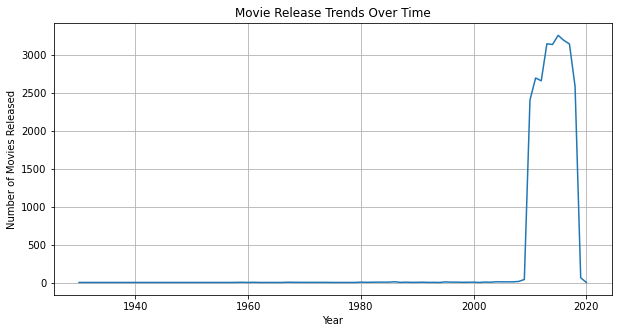

In [115]:
#trends in releases
df_tmdb['release_date'] = pd.to_datetime(df_tmdb['release_date'], errors='coerce')
df_tmdb['release_date'].dt.year.value_counts().sort_index().plot(kind='line', figsize=(10, 5))
plt.xlabel('Year')
plt.ylabel('Number of Movies Released')
plt.title('Movie Release Trends Over Time')
plt.grid(True)
plt.show()


# tn.movie_budgets.csv.gz
Top grossing movies

Profitability trends over time

Budget vs. revenue correlations

Domestic vs. international performance

Comparing profitability across genres

In [116]:
import pandas as pd  

# Load the dataset  
df_budgets = pd.read_csv('./zippedData/tn.movie_budgets.csv.gz')  

# Display the first few rows  
df_budgets.head()


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [117]:
df_budgets.info()
df_budgets.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


Index(['id', 'release_date', 'movie', 'production_budget', 'domestic_gross',
       'worldwide_gross'],
      dtype='object')

In [118]:
#most  expensive movies
df_budgets.sort_values(by='production_budget', ascending=False)[['movie', 'production_budget']].head(10)


,movie,production_budget
406,The Peanuts Movie,"$99,000,000"
407,The LEGO Movie 2: The Second Part,"$99,000,000"
408,Robin Hood,"$99,000,000"
5326,And Then Came Love,"$989,000"
409,The Mummy Returns,"$98,000,000"
410,Gangs of New York,"$97,000,000"
411,Alien: Covenant,"$97,000,000"
5332,Ask Me Anything,"$950,000"
5331,Jesse,"$950,000"
5327,Hard Candy,"$950,000"


In [119]:
#highest grossing movies(movies that made most money)
df_budgets.sort_values(by='worldwide_gross', ascending=False)[['movie', 'worldwide_gross']].head(10)


,movie,worldwide_gross
3737,Fifty Dead Men Walking,"$997,921"
3432,Duma,"$994,790"
5062,Insidious,"$99,870,886"
883,Hellboy,"$99,823,958"
5613,Mad Max,"$99,750,000"
1078,Alpha,"$99,624,873"
1682,Street Fighter,"$99,423,000"
1792,Nacho Libre,"$99,296,462"
4373,Desert Blue,"$99,147"
2343,Hitman,"$99,135,571"


In [123]:
#movies with highest return on investment
# Remove currency symbols and convert to numeric
df_budgets[['production_budget', 'domestic_gross', 'worldwide_gross']] = (
    df_budgets[['production_budget', 'domestic_gross', 'worldwide_gross']]
    .replace({'\$': '', ',': ''}, regex=True)
    .astype(float)
)

# Calculate profit and profit margin
df_budgets['profit'] = df_budgets['worldwide_gross'] - df_budgets['production_budget']
df_budgets['profit_margin'] = (df_budgets['profit'] / df_budgets['production_budget']) * 100

# View top movies by ROI
df_budgets.sort_values(by='profit_margin', ascending=False)[['movie', 'profit', 'profit_margin']].head(10)



,movie,profit,profit_margin
5745,Deep Throat,44975000.0,179900.000000
5613,Mad Max,99550000.0,49775.000000
5492,Paranormal Activity,193733034.0,43051.785333
5679,The Gallows,41556474.0,41556.474000
5406,The Blair Witch Project,247700000.0,41283.333333
5709,Super Size Me,22168808.0,34105.858462
5346,Bambi,267142000.0,31135.431235
5773,El Mariachi,2034928.0,29070.400000
5676,Night of the Living Dead,29973064.0,26292.161404
5210,Rocky,224000000.0,22400.000000


In [126]:
print(df_budgets.dtypes)


id                            int64
release_date         datetime64[ns]
movie                        object
production_budget           float64
domestic_gross              float64
worldwide_gross             float64
profit                      float64
profit_margin               float64
dtype: object


In [127]:
print(df_budgets[['domestic_gross', 'worldwide_gross']].isna().sum())


domestic_gross     0
worldwide_gross    0
dtype: int64


In [128]:
df_budgets['release_date'] = pd.to_datetime(df_budgets['release_date'], errors='coerce')


In [129]:
print(df_budgets.groupby(df_budgets['release_date'].dt.year)[['domestic_gross', 'worldwide_gross']].sum())


              domestic_gross  worldwide_gross
release_date                                 
1915            1.000000e+07     1.100000e+07
1916            8.000000e+06     8.000000e+06
1920            3.000000e+06     3.000000e+06
1925            2.000000e+07     3.100000e+07
1927            0.000000e+00     0.000000e+00
...                      ...              ...
2016            1.104283e+10     2.876815e+10
2017            1.045340e+10     2.842963e+10
2018            1.055178e+10     2.609444e+10
2019            2.867619e+09     6.676825e+09
2020            0.000000e+00     0.000000e+00

[96 rows x 2 columns]


<AxesSubplot:xlabel='release_date'>

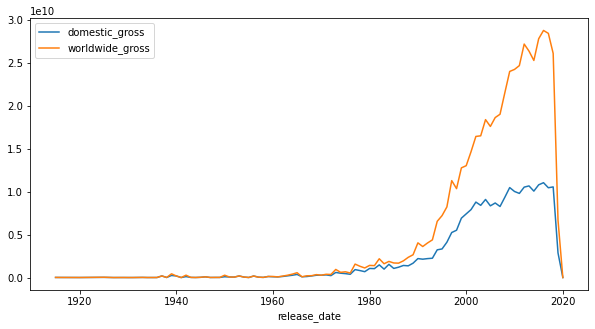

In [131]:
#domestic vs international performance
grouped_df = df_budgets.groupby(df_budgets['release_date'].dt.year)[['domestic_gross', 'worldwide_gross']].sum()
grouped_df.plot(kind='line', figsize=(10, 5))


# KEY INSIGHTS 
## 1.High- Earning Films have a strong international appeal
-Foreign box office revenue often exceeds domestic earnings, with top movies like Avengers: Endgame and Frozen generating most of their profits globally.

-Action, fantasy, and franchise movies dominate international markets.

## 2. Popular Genres Drive Box Office Success

-Drama and Documentary are the most common genres, but high-grossing films tend to be Action, Adventure, Fantasy, and Comedy.

-Multi-genre movies (e.g., Action-Comedy) tend to perform better than single-genre films.

## 3.Higher Budgets Often Lead to Higher Revenue—But Not Always

While big-budget films generally have higher box office earnings, some lower-budget films achieve significant profitability.

A focus on cost-efficient production strategies could maximize returns.

## 4.Critical Reception Plays a Role in Longevity

Films with higher IMDb ratings and substantial audience votes tend to generate stronger long-term earnings.

PG-13 films often strike a balance between broad audience reach and profitability.

## 5.Review Trends Highlight Audience Preferences

Audience reviews align with strong box office performance—well-received films experience longer theatrical runs.

Positive reviews from major publishers (New York Times, Variety) often signal strong commercial potential.

# KEY RECOMMENDATIONS

## 1.Invest in Globally Marketable Genres

Prioritize Action, Adventure, Fantasy, and Sci-Fi, which perform well in both domestic and international markets.

Develop multi-genre films to appeal to wider audiences.

## 2. Optimize Budget Allocation

Large budgets can result in blockbuster earnings, but mid-budget films with strong storytelling can still be highly profitable.

Consider cost-saving strategies like strategic casting and filming locations.

## 3.Leverage Audience Ratings & Reviews

Aim for high audience ratings through strong storytelling and quality production.

Engage with film critics early to generate positive buzz before release.

## 4. Focus on PG-13 Ratings for Maximum Reach

PG-13 films historically yield better financial outcomes, making them an ideal choice for broad market appeal.

Adjust content to meet audience preferences without limiting accessibility.

## 5. Monitor International Box Office Trends

Strengthen international distribution and marketing strategies for wider box office success.

Consider regional audience preferences when selecting themes and storylines.